In [1]:
raw_string = """
```json
{
  "answer": "C",
  "explanation": "The woman is wearing blue jeans. The jeans are a common type of clothing item that is typically worn as pants. They are a popular choice for casual wear and are often associated with a relaxed, comfortable style. The jeans in the image are likely a key feature of the woman's outfit, as they are a common and recognizable type of clothing.",
  "confidence": 0.9
}
```
"""

In [2]:
json_string = raw_string.strip().removeprefix('```json').removesuffix('```').strip()
print(json_string)

{
  "answer": "C",
  "explanation": "The woman is wearing blue jeans. The jeans are a common type of clothing item that is typically worn as pants. They are a popular choice for casual wear and are often associated with a relaxed, comfortable style. The jeans in the image are likely a key feature of the woman's outfit, as they are a common and recognizable type of clothing.",
  "confidence": 0.9
}


In [3]:
import json
data = json.loads(json_string)
# Access and print the data
print("Answer:", data['answer'])
print("Explanation:", data['explanation'])
print("Confidence:", data['confidence'])

Answer: C
Explanation: The woman is wearing blue jeans. The jeans are a common type of clothing item that is typically worn as pants. They are a popular choice for casual wear and are often associated with a relaxed, comfortable style. The jeans in the image are likely a key feature of the woman's outfit, as they are a common and recognizable type of clothing.
Confidence: 0.9


In [8]:
def custom_kernel_s3():
    pass

In [11]:
def extract_sentence_features(sentence):
    doc = nlp(sentence)
    key_words = [token.lemma_ for token in doc if token.pos_ in ['NOUN', 'VERB', 'ADJ', 'ADV']]
    return doc.vector, key_words, [token.pos_ for token in doc]

In [9]:
sentences = {
    "S1": {
        "ground_truth": "The dog barked loudly at the stranger.",
        "variations": [
            "A girl is dancing in the stadium.",
            "A girl is dancing in the stadium.",
            "A girl is dancing in the stadium.",
        ],
        "kernel": custom_kernel_s3
    }
}

In [19]:
import spacy
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

nlp = spacy.load("en_core_web_sm")

features = {}

features = {}
for key, data in sentences.items():
    features[key] = [extract_sentence_features(data["ground_truth"])] + [extract_sentence_features(s) for s in data["variations"]]

In [20]:
len(features['S1'])

4

In [ ]:
    print(data['ground_truth'])
    print(data['variations'])
    print(data['kernel'])
    print(data['kernel']())
    features[key] = [extract_sentence_features(data['ground_truth']) + extract_sentence_features(s) for s in data['variations']]

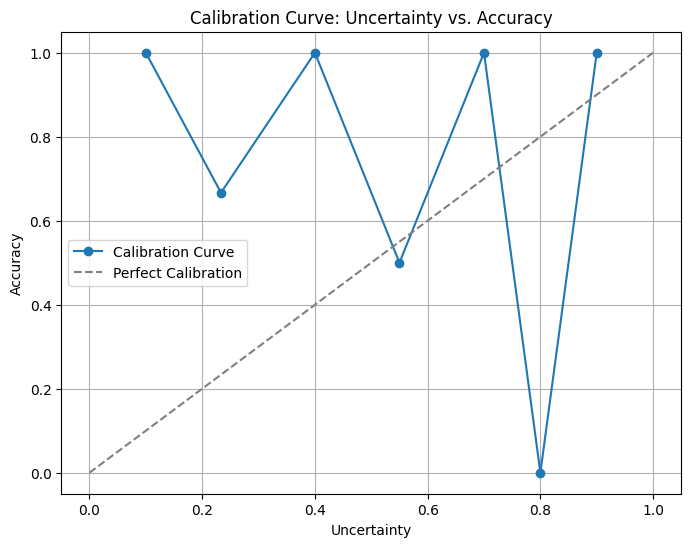

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# Assuming you have the following lists
# - predictions: a list of model predictions
# - true_labels: a list of true labels
# - uncertainties: a list of uncertainty values corresponding to the predictions

def calculate_accuracy(predictions, true_labels):
    return np.mean(np.array(predictions) == np.array(true_labels))

def bin_data(uncertainties, accuracies, num_bins=10):
    bins = np.linspace(0, 1, num_bins + 1)
    bin_indices = np.digitize(uncertainties, bins) - 1

    bin_uncertainties = []
    bin_accuracies = []

    for i in range(num_bins):
        bin_mask = bin_indices == i
        if np.any(bin_mask):
            bin_uncertainties.append(np.mean(uncertainties[bin_mask]))
            bin_accuracies.append(np.mean(accuracies[bin_mask]))

    return bin_uncertainties, bin_accuracies

def plot_calibration_curve(uncertainties, accuracies, num_bins=10):
    bin_uncertainties, bin_accuracies = bin_data(uncertainties, accuracies, num_bins)
    
    plt.figure(figsize=(8, 6))
    plt.plot(bin_uncertainties, bin_accuracies, marker='o', label='Calibration Curve')
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect Calibration')
    plt.xlabel('Uncertainty')
    plt.ylabel('Accuracy')
    plt.title('Calibration Curve: Uncertainty vs. Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()

# Example data
predictions = np.array([0, 1, 0, 1, 1, 0, 1, 0, 1, 0])
true_labels = np.array([0, 1, 1, 1, 0, 0, 1, 0, 1, 1])
uncertainties = np.array([0.1, 0.2, 0.8, 0.3, 0.5, 0.6, 0.4, 0.9, 0.7, 0.2])

# Calculate accuracy for each prediction
accuracies = np.array([1 if pred == true else 0 for pred, true in zip(predictions, true_labels)])

# Plot the calibration curve
plot_calibration_curve(uncertainties, accuracies, num_bins=10)


In [3]:
import pandas as pd

data_path = '/home/ubuntu/Multimodal-Uncertainty-Quantification/datasets_/MMT-Bench/MMT-Bench_VAL.tsv'
df = pd.read_csv(data_path, sep='\t')

In [4]:
import json

def load_json_file(file_path):
    with open(file_path, 'r') as file:
        data = json.load(file)
    return data

response_path = '/home/ubuntu/Multimodal-Uncertainty-Quantification/results/llava_mmt_output.json'
model_responses = load_json_file(response_path)

# load only hallucination datapoints
df = df['category'].str.contains('hallucination')